# Feature Engineering

모든 배치에 `src.features`의 동일한 파이프라인을 적용한다. 한 행은 한 셀이다.

In [1]:
from pathlib import Path
import sys
import json
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RESULTS = ROOT / 'results'


## Definitions

`ΔQ100−10(V)`는 공통 전압 범위의 1,000점 grid로 보간한 뒤 point-wise 차이를 계산한다. `log_dq_var = log10(max(var(ΔQ), 1e-12))`이다.

In [2]:
from src.features import EPSILON, MODEL_FEATURES, parse_policy
print('variance epsilon:', EPSILON)
print('model features:', MODEL_FEATURES)

variance epsilon: 1e-12
model features: ['log_dq_var', 'dq_mean', 'dq_min', 'dq_range', 'qd_10', 'qd_100', 'qd_slope_10_100', 'ir_10', 'ir_change_10_100', 'tavg_mean_10_100', 'tmax_max_10_100', 'charge_time_mean_10_100', 'first_c_rate', 'switch_soc', 'second_c_rate']


## Feature datasets and quality checks

In [3]:
features = {b: pd.read_csv(RESULTS/f'feature_dataset_{b}.csv') for b in ('batch1','batch2','batch3')}
quality = {b: pd.read_csv(RESULTS/'tables'/f'quality_report_{b}.csv') for b in ('batch1','batch2','batch3')}
pd.DataFrame({b: {'rows': len(features[b]), 'valid': int(quality[b].valid_for_model.sum()), 'columns': len(features[b].columns)} for b in features}).T

,rows,valid,columns
batch1,46,41,30
batch2,47,34,30
batch3,46,40,30


In [4]:
features['batch1'].head()

,cell_id,batch,cycle_life,charging_policy,first_c_rate,switch_soc,second_c_rate,qd_10,qd_100,qd_change_10_100,...,charge_time_change_10_100,dq_mean,dq_min,dq_max,dq_std,dq_var,log_dq_var,dq_range,dq_skew,dq_kurtosis
0,Batch1_cell_000,Batch1,1190.0,3.6C(80%)-3.6C,3.6,0.8,3.6,1.074537,1.075913,0.001375,...,-0.084872,-0.002873,-0.008460,0.000768,0.003109,0.000010,-5.014861,0.009228,-0.532058,-1.348312
1,Batch1_cell_001,Batch1,1179.0,3.6C(80%)-3.6C,3.6,0.8,3.6,1.079777,1.080630,0.000853,...,-0.084583,-0.004100,-0.011004,-0.000088,0.003112,0.000010,-5.013960,0.010916,-0.429375,-1.029116
2,Batch1_cell_002,Batch1,1177.0,3.6C(80%)-3.6C,3.6,0.8,3.6,1.083782,1.084940,0.001159,...,0.000212,-0.004487,-0.017216,0.000013,0.004281,0.000018,-4.737000,0.017229,-1.080194,0.348637
3,Batch1_cell_003,Batch1,1226.0,4C(80%)-4C,4.0,0.8,4.0,1.084308,1.084750,0.000442,...,0.000137,-0.007456,-0.018961,0.000182,0.006007,0.000036,-4.442613,0.019143,-0.439050,-1.095416
4,Batch1_cell_004,Batch1,1227.0,4C(80%)-4C,4.0,0.8,4.0,1.081954,1.082646,0.000692,...,-0.084063,-0.005750,-0.013958,0.000046,0.004744,0.000023,-4.647744,0.014004,-0.362548,-1.333831


## Batch comparison

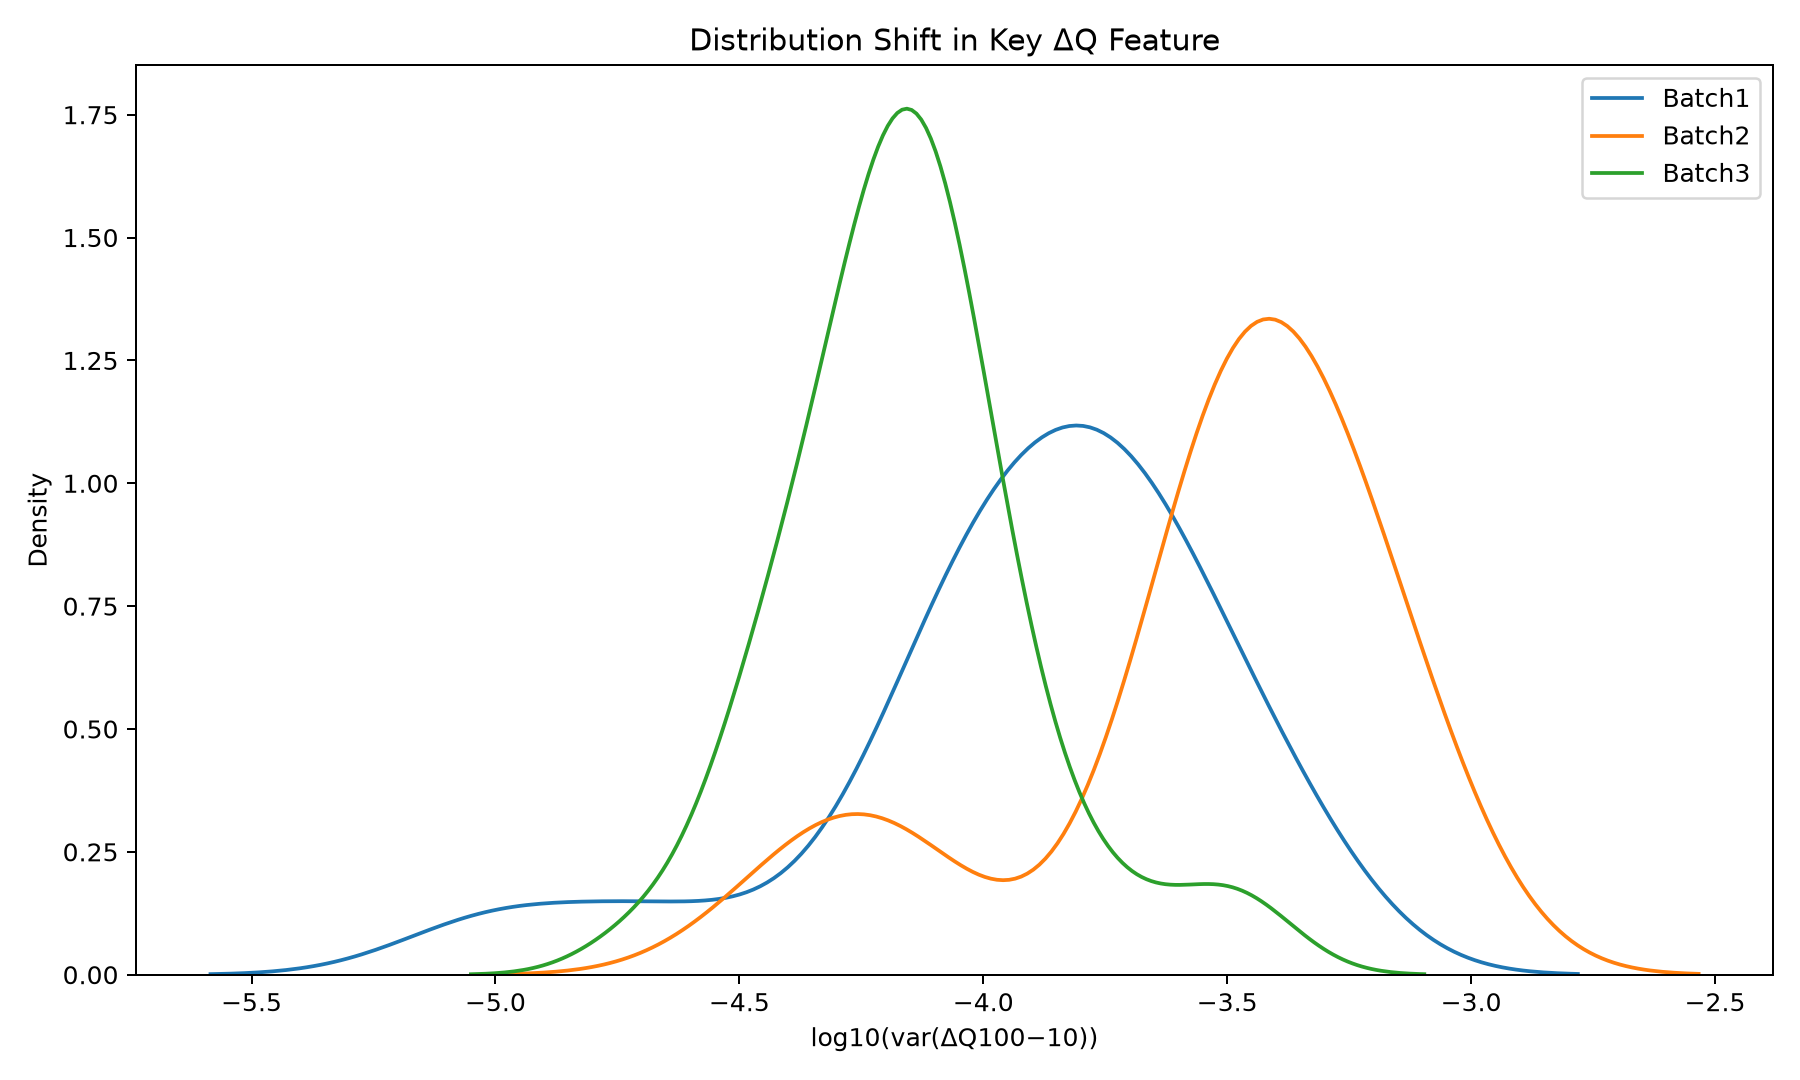

In [5]:
display(Image(filename=RESULTS/'figures/batch_feature_distribution_shift.png'))

## EDA에서 모델 입력으로

Knee처럼 수명 종료 이후에 알 수 있는 값과 `cycle_life`는 입력에서 제외한다. 세 Batch에는 동일한 Feature 추출 함수를 적용하며, Batch 2·3는 고정 모델의 외부 평가에만 사용한다.

In [6]:
strategy = json.loads((RESULTS/'tables/day1_model_strategy.json').read_text())
strategy

{'input_x': ['log_dq_var',
  'dq_mean',
  'dq_min',
  'dq_range',
  'qd_10',
  'qd_100',
  'qd_slope_10_100',
  'ir_10',
  'ir_change_10_100',
  'tavg_mean_10_100',
  'tmax_max_10_100',
  'charge_time_mean_10_100',
  'first_c_rate',
  'switch_soc',
  'second_c_rate'],
 'raw_target_y': 'cycle_life',
 'model_target': 'log(cycle_life)',
 'forbidden_model_features': ['cycle_life', 'knee_cycle', 'knee_fraction'],
 'candidate_models': ['LinearRegression', 'ElasticNet', 'GradientBoosting'],
 'selection_data': 'Batch1 train/validation only',
 'validation_group': 'charging_policy',
 'external_evaluation': ['Batch2', 'Batch3'],
 'external_results_used_for_tuning': False}